# Can we predict where a currency goes next?

**Notebook 1 of 2 — direction.**

EURUSD, USDJPY and USDINR, daily data since 2015. Target: the direction of the
move over the next 5 trading days — up, down, or flat, where "flat" means the
move was smaller than the market's current noise level (a dead zone that widens
in wild stretches and narrows in calm ones). Every model is scored walk-forward
— refit as time advances, graded only on data it has never seen — against a
stated simple guess.

Data is committed under `data/raw/` — Yahoo prices, plus interest rates and
fund-positioning data from public US sources — so this runs offline.

## 1. Data wrangling

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
RAW = Path("../data/raw")
PAIRS = {"EURUSD": "EURUSD_X", "USDJPY": "JPY_X", "USDINR": "INR_X"}

closes = {name: pd.read_parquet(RAW / f"{f}.parquet")["close"].dropna()
          for name, f in (PAIRS | {"DXY": "DX-Y_NYB", "VIX": "_VIX"}).items()}
{k: (len(v), str(v.index[0].date()), str(v.index[-1].date())) for k, v in closes.items()}

{'EURUSD': (3014, '2015-01-01', '2026-07-31'),
 'USDJPY': (3014, '2015-01-01', '2026-07-31'),
 'USDINR': (3014, '2015-01-01', '2026-07-31'),
 'DXY': (2912, '2015-01-02', '2026-07-31'),
 'VIX': (2912, '2015-01-02', '2026-07-31')}

### Aligning the dollar index and the VIX

Two extra inputs join the currency prices: DXY (the dollar index — one number
tracking the dollar against a basket of currencies) and the VIX (a widely used
market-nervousness gauge). Yahoo stamps currency closes earlier in the day than
these two, so joined naively on date, "today's" dollar move overlaps the very
move being predicted. The check below uses correlation, a score from −1 to +1
where near 0 means no connection and far from 0 means a strong one: the dollar
move stamped today is strongly connected to *tomorrow's* euro move, not
today's. Both index series get a one-day lag before any join.

In [2]:
idx = closes["EURUSD"].index.intersection(closes["DXY"].index).intersection(closes["VIX"].index)
eur = np.log(closes["EURUSD"].loc[idx]).diff()
dxy = np.log(closes["DXY"].loc[idx]).diff()

print(f"corr(dxy_t, eurusd_t)   = {eur.corr(dxy):+.2f}")
print(f"corr(dxy_t, eurusd_t+1) = {eur.shift(-1).corr(dxy):+.2f}")

# Fix: lag the index series one trading day before any join.
lagged = {"DXY": closes["DXY"].shift(1), "VIX": closes["VIX"].shift(1)}

corr(dxy_t, eurusd_t)   = -0.09
corr(dxy_t, eurusd_t+1) = -0.87


In [3]:
def feature_frame(pair):
    """Daily features + the 5-day-ahead direction label for one pair."""
    px = closes[pair]
    common = px.index.intersection(closes["DXY"].index).intersection(closes["VIX"].index)
    px = px.loc[common]
    r = np.log(px).diff()

    f = pd.DataFrame(index=common)
    f["close"] = px
    f["log_return"] = r
    for w in (5, 20, 60):
        f[f"vol_{w}d"] = r.rolling(w).std()
    f["ret_z"] = (r - r.rolling(252).mean()) / r.rolling(252).std()
    f["dxy_return"] = np.log(lagged["DXY"].reindex(common)).diff()
    f["vix"] = lagged["VIX"].reindex(common)
    f["corr_dxy"] = r.rolling(60).corr(f["dxy_return"])
    f["dow"] = common.dayofweek
    f["month"] = common.month

    # Label: direction of the 5-day-ahead move, with a dead zone scaled to
    # current volatility so "flat" means "too small to matter right now".
    fwd = np.log(px).shift(-5) - np.log(px)
    dead = 0.25 * f["vol_20d"] * np.sqrt(5)
    f["label"] = np.select([fwd > dead, fwd < -dead], [2, 0], default=1).astype(float)
    f.loc[fwd.isna() | dead.isna(), "label"] = np.nan
    return f.dropna()

frames = {p: feature_frame(p) for p in PAIRS}
frames["EURUSD"].tail(3).round(4)

,close,log_return,vol_5d,vol_20d,vol_60d,ret_z,dxy_return,vix,corr_dxy,dow,month,label
date,,,,,,,,,,,,
2026-07-22,1.1404,-0.0013,0.0025,0.0027,0.0028,-0.2969,0.0019,17.05,-0.8729,2,7,0.0
2026-07-23,1.1412,0.0007,0.0011,0.0025,0.0028,0.2008,-0.0004,16.64,-0.8717,3,7,2.0
2026-07-24,1.1377,-0.0031,0.0014,0.0026,0.0028,-0.7453,0.0029,18.70,-0.8742,4,7,2.0


## 2. Data validation

In [4]:
checks = []
for pair, f in frames.items():
    gaps = f.index.to_series().diff().dt.days.max()
    checks.append({
        "pair": pair,
        "rows": len(f),
        "start": f.index[0].date(),
        "end": f.index[-1].date(),
        "max_gap_days": int(gaps),
        "dupes": int(f.index.duplicated().sum()),
        "nans": int(f.isna().sum().sum()),
        "share_up": round((f["label"] == 2).mean(), 3),
        "share_flat": round((f["label"] == 1).mean(), 3),
        "share_down": round((f["label"] == 0).mean(), 3),
    })
    assert f.index.is_monotonic_increasing and not f.index.duplicated().any()
    assert f.drop(columns="label").notna().all().all()
    assert gaps <= 14, f"{pair}: calendar gap of {gaps} days"
pd.DataFrame(checks)

,pair,rows,start,end,max_gap_days,dupes,nans,share_up,share_flat,share_down
0,EURUSD,2648,2016-01-04,2026-07-24,5,0,0,0.398,0.198,0.404
1,USDJPY,2648,2016-01-04,2026-07-24,5,0,0,0.439,0.217,0.344
2,USDINR,2648,2016-01-04,2026-07-24,5,0,0,0.414,0.259,0.327


- No duplicate dates
- No gaps beyond ordinary holidays
- No missing values
- UP and DOWN are close to balanced.

## 3. Exploratory analysis

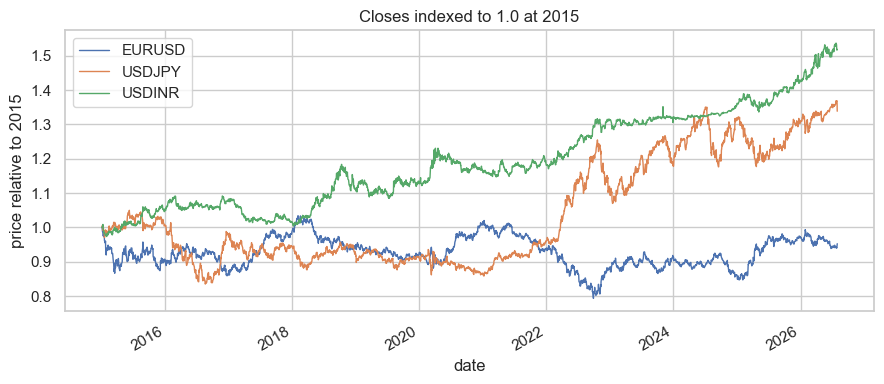

In [5]:
# Context before any modelling: the three pairs had very different decades,
# so nothing below assumes they behave alike.
norm = pd.DataFrame({p: closes[p] / closes[p].iloc[0] for p in PAIRS}).dropna()
ax = norm.plot(figsize=(9, 4), linewidth=1)
ax.set_title("Closes indexed to 1.0 at 2015")
ax.set_ylabel("price relative to 2015")
plt.tight_layout()

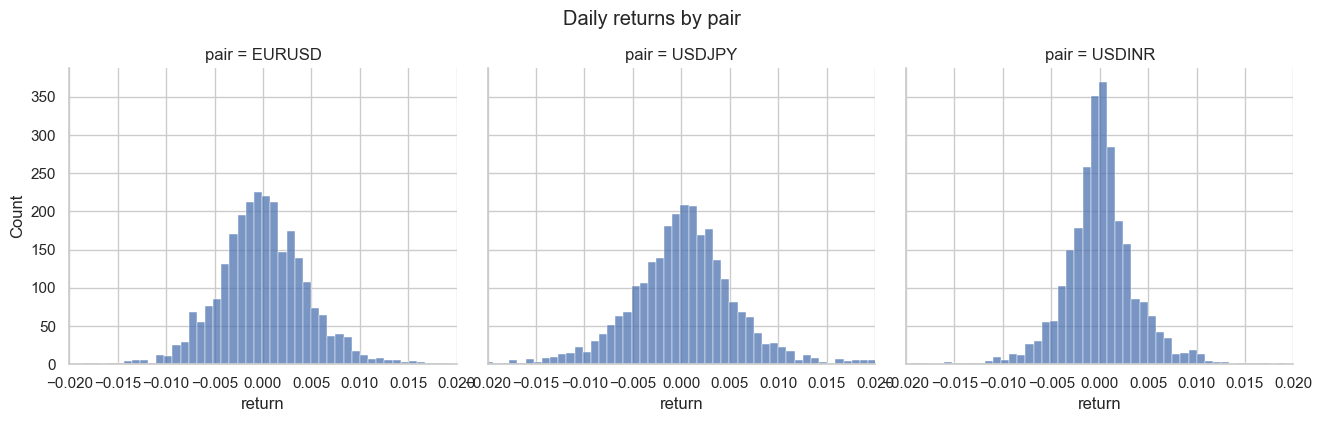

In [6]:
# What counts as a "small" move depends on how big typical days are — so the
# flat-zone threshold has to scale with recent conditions, not be fixed.
rets = pd.concat(
    [frames[p]["log_return"].rename("return").to_frame().assign(pair=p) for p in PAIRS]
)
g = sns.displot(rets, x="return", col="pair", kind="hist", bins=80,
                facet_kws={"sharex": True}, height=4, aspect=1.1)
g.set(xlim=(-0.02, 0.02))
g.figure.suptitle("Daily returns by pair", y=1.05);

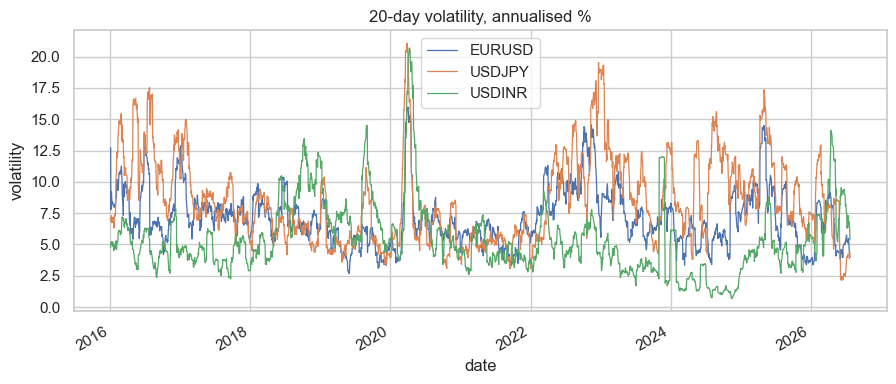

In [7]:
# Calm and stormy stretches cluster. A fixed dead zone would mislabel half
# the sample; this is also a preview of notebook 2's target.
vol = pd.DataFrame({p: frames[p]["vol_20d"] * np.sqrt(252) * 100 for p in PAIRS})
ax = vol.plot(figsize=(9, 4), linewidth=0.9)
ax.set_title("20-day volatility, annualised %")
ax.set_ylabel("volatility")
plt.tight_layout()

### Autocorrelation: returns vs |returns|

Autocorrelation asks: how much does a series correlate with its own past, some
number of days (the "lag") back? If direction has memory, daily returns (signed
moves) autocorrelate. If only size has memory, absolute returns do and signed
returns don't.

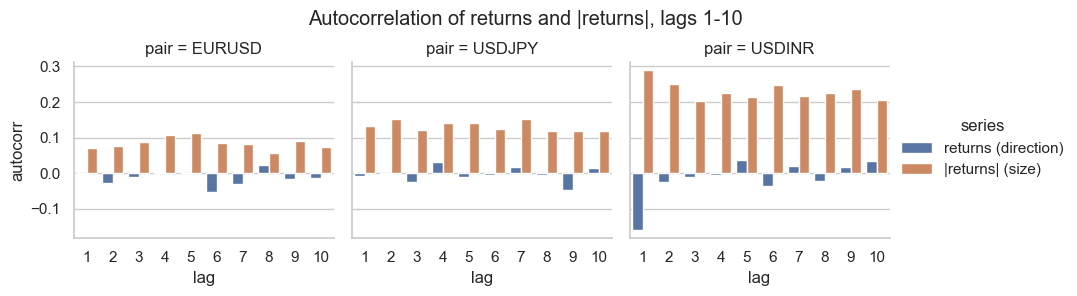

In [8]:
# The decisive check: autocorrelation of returns (direction) vs |returns|
# (size). Whatever shows memory here is what a model can hope to predict.
rows = []
for p in PAIRS:
    r = frames[p]["log_return"]
    for lag in range(1, 11):
        rows.append({"pair": p, "lag": lag, "series": "direction of moves",
                     "autocorr": r.autocorr(lag)})
        rows.append({"pair": p, "lag": lag, "series": "size of moves",
                     "autocorr": r.abs().autocorr(lag)})
ac = pd.DataFrame(rows)
g = sns.catplot(ac, x="lag", y="autocorr", hue="series", col="pair",
                kind="bar", height=2.8, aspect=1.1)
g.figure.suptitle("Autocorrelation of daily moves - direction vs size, lags 1-10", y=1.05);

Size has memory at every lag; direction has none. That asymmetry shapes
everything below — direction models are fighting noise. Notebook 2 takes the
easier target.

## 4. Basic models

From here the notebook uses the packaged pipeline (`src/regime_lab`) — it applies
exactly the steps above, with tests, so these numbers match the published tables.
The protocol is six expanding walk-forward blocks — train on everything so far,
test on the next stretch, repeat — with a few rows dropped at each boundary so
labels near a split can't leak across it. Blocks 1–5 are for exploring; **block
6 (2025-01 to 2026-04) is the final test set, kept out of every decision**, and
all headline claims are scored there.

Three models to start, two of them deliberately dumb:
- **persistence** (the floor) — predict that the next period repeats the last
  one's direction;
- **majority** — always predict the window's most common outcome;
- **logistic regression** — a simple model that combines the inputs into
  UP/FLAT/DOWN probabilities; the honest first learner.

The metric is **balanced accuracy**: the hit rate on UP days, FLAT days and
DOWN days, averaged — so always calling the commonest outcome earns nothing.
Random guessing scores 33%.

In [9]:
import sys

sys.path.insert(0, "../src")
from sklearn.metrics import balanced_accuracy_score

from regime_lab.config import Settings
from regime_lab.data.splits import split_by_block
from regime_lab.dataset import TARGET_COLUMN, load_pair_dataset
from regime_lab.models import MODEL_FEATURES, MajorityPersistenceBaseline, make_b1

settings = Settings()
datasets = {p: load_pair_dataset(p, settings, Path("..")) for p in PAIRS}
blocks = settings.walk_forward_blocks

def walk_forward(pair, fit_predict):
    """Balanced accuracy per block for one model on one pair."""
    out = {}
    df = datasets[pair]
    for block in blocks:
        train, test = split_by_block(df, block, purge=settings.direction_k)
        pred = fit_predict(train, test)
        out[block.block_id] = balanced_accuracy_score(test[TARGET_COLUMN], pred)
    return out

def floor_model(train, test):
    m = MajorityPersistenceBaseline().fit(train, train[TARGET_COLUMN])
    return m.predict(test)

def majority_model(train, test):
    return np.full(len(test), train[TARGET_COLUMN].mode()[0])

def logistic_model(train, test):
    m = make_b1(settings.seed).fit(train[MODEL_FEATURES], train[TARGET_COLUMN])
    return m.predict(test[MODEL_FEATURES])

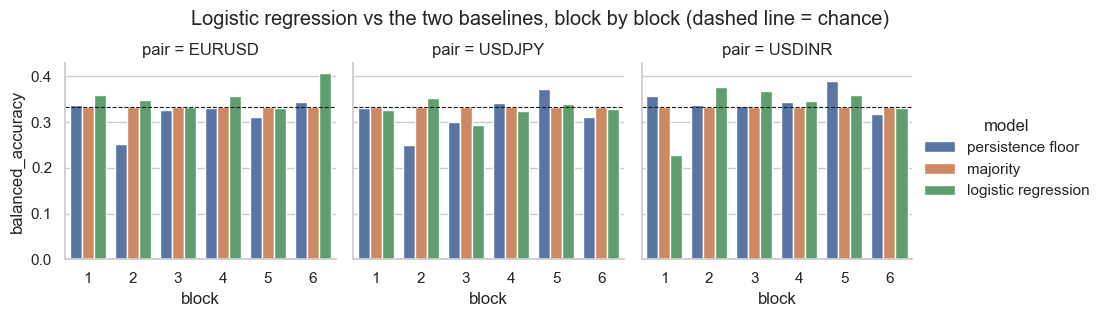

In [10]:
# Score per walk-forward block, not averaged, so instability stays visible.
basic = []
for pair in PAIRS:
    for name, fn in [("persistence floor", floor_model),
                     ("majority", majority_model),
                     ("logistic regression", logistic_model)]:
        for block, score in walk_forward(pair, fn).items():
            basic.append({"pair": pair, "model": name, "block": block,
                          "balanced_accuracy": score})
basic = pd.DataFrame(basic)

g = sns.catplot(basic, x="block", y="balanced_accuracy", hue="model", col="pair",
                kind="bar", height=3, aspect=1.05)
for ax in g.axes.flat:
    ax.axhline(1 / 3, color="k", linewidth=0.8, linestyle="--")
g.figure.suptitle("Logistic regression vs the two baselines, block by block "
                  "(dashed line = chance)", y=1.05);

Logistic regression sits above the persistence floor in some blocks and below
it in others. Nothing stable yet.

## 5. Ensemble models

Gradient boosting and random forest, plus an ensemble that averages the
models' probabilities — forecast averaging is the most reliably replicated
trick in the forecasting literature, so it gets a row.

In [11]:
from regime_lab.models import _expand_proba, make_b2, make_nb, make_rf


def proba_model(factory):
    def fn(train, test):
        m = factory(settings.seed).fit(train[MODEL_FEATURES], train[TARGET_COLUMN])
        return _expand_proba(m, test[MODEL_FEATURES]).argmax(axis=1)
    return fn

def ensemble_model(train, test):
    probas = [
        _expand_proba(f(settings.seed).fit(train[MODEL_FEATURES], train[TARGET_COLUMN]),
                      test[MODEL_FEATURES])
        for f in (make_b1, make_b2, make_rf, make_nb)
    ]
    return np.mean(probas, axis=0).argmax(axis=1)

rich = []
for pair in PAIRS:
    for name, fn in [("gradient boosting", proba_model(make_b2)),
                     ("random forest", proba_model(make_rf)),
                     ("ensemble", ensemble_model)]:
        for block, score in walk_forward(pair, fn).items():
            rich.append({"pair": pair, "model": name, "block": block,
                         "balanced_accuracy": score})
rich = pd.DataFrame(rich)
rich.groupby(["pair", "model"])["balanced_accuracy"].mean().round(3).unstack()

model,ensemble,gradient boosting,random forest
pair,,,
EURUSD,0.335,0.330,0.344
USDINR,0.325,0.336,0.332
USDJPY,0.339,0.326,0.334


Every number in that table sits at the 33% random-guessing floor. The extra
compute bought nothing on accuracy — which makes the next question sharper:
are the probabilities these models state at least honest?

### Calibration

A model that says "70% up" should be right about 70% of those times. Block-6
predictions binned by stated P(up) against the realised up-frequency.

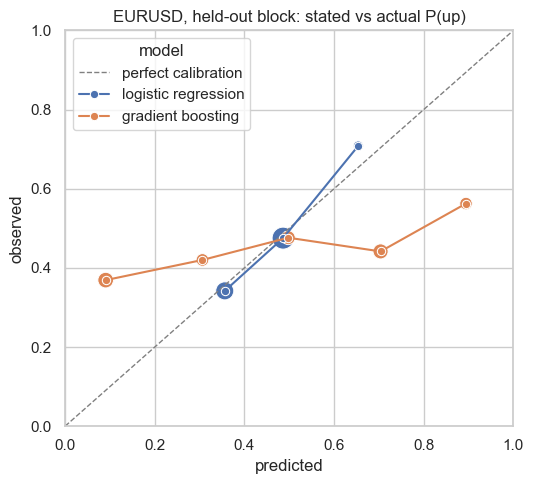

In [12]:
# Sizing any decision by a stated probability assumes the probability is
# honest. Bin stated P(up) against what actually happened.
block6 = blocks[-1]
cal_rows = []
for name, factory in [("logistic regression", make_b1), ("gradient boosting", make_b2)]:
    train, test = split_by_block(datasets["EURUSD"], block6, purge=settings.direction_k)
    m = factory(settings.seed).fit(train[MODEL_FEATURES], train[TARGET_COLUMN])
    p_up = _expand_proba(m, test[MODEL_FEATURES])[:, 2]
    up = (test[TARGET_COLUMN] == 2).astype(int)
    bins = pd.cut(p_up, np.arange(0, 1.01, 0.2))
    for _, g in pd.DataFrame({"p": p_up, "up": up}).groupby(bins, observed=True):
        if len(g) >= 10:
            cal_rows.append({"model": name, "predicted": g["p"].mean(),
                             "observed": g["up"].mean(), "n": len(g)})
cal = pd.DataFrame(cal_rows)

fig, ax = plt.subplots(figsize=(5.5, 5))
ax.plot([0, 1], [0, 1], "--", color="gray", linewidth=1, label="perfect calibration")
sns.lineplot(cal, x="predicted", y="observed", hue="model", marker="o", ax=ax)
sns.scatterplot(cal, x="predicted", y="observed", hue="model", size="n",
                sizes=(50, 250), legend=False, ax=ax)
ax.set(xlim=(0, 1), ylim=(0, 1), title="EURUSD, held-out block: stated vs actual P(up)")
plt.tight_layout()

Logistic tracks the diagonal. Gradient boosting says 10% on days that come up
37% of the time, and 90% on days that come up 56% — overconfident at both ends.
An accuracy table never shows this.

## 6. Other models

Naive Bayes as a second cheap yardstick, and a hidden Markov model — a model
that assumes the market switches between a few hidden "moods" and infers them
from returns alone. It is the standard tool for finding market regimes, so it
has to be tried.

In [13]:
import logging

from hmmlearn.hmm import GaussianHMM

# hmmlearn logs a "not converging" warning when it stops at the iteration cap;
# with this much data the fit is stable well before the cap, so silence it.
logging.getLogger("hmmlearn").setLevel(logging.ERROR)

nb_scores = {p: np.mean(list(walk_forward(p, proba_model(make_nb)).values())) for p in PAIRS}
print("naive Bayes, mean balanced accuracy:",
      {p: round(v, 3) for p, v in nb_scores.items()})

# What do the HMM's hidden states actually learn? Fit one per pair and look at
# each state's direction odds and volatility.
state_rows = []
for pair in PAIRS:
    r = frames[pair]["log_return"]
    hmm = GaussianHMM(n_components=3, covariance_type="diag", n_iter=200,
                      random_state=settings.seed).fit(r.to_numpy().reshape(-1, 1))
    states = hmm.predict(r.to_numpy().reshape(-1, 1))
    lab = frames[pair]["label"]
    for s in range(3):
        mask = states == s
        state_rows.append({
            "pair": pair, "state": s, "share_of_days": mask.mean(),
            "daily_vol_bp": r[mask].std() * 1e4,
            "p_up_minus_base": (lab[mask] == 2).mean() - (lab == 2).mean(),
        })
states_df = pd.DataFrame(state_rows).round(3)
states_df

naive Bayes, mean balanced accuracy: {'EURUSD': 0.364, 'USDJPY': 0.346, 'USDINR': 0.335}


,pair,state,share_of_days,daily_vol_bp,p_up_minus_base
0,EURUSD,0,0.499,44.563,0.002
1,EURUSD,1,0.499,46.395,-0.003
2,EURUSD,2,0.002,263.050,0.202
3,USDJPY,0,0.483,53.648,0.003
4,USDJPY,1,0.487,50.820,0.008
5,USDJPY,2,0.030,143.451,-0.176
6,USDINR,0,0.493,34.116,-0.010
7,USDINR,1,0.494,35.411,0.011
8,USDINR,2,0.013,141.662,-0.014


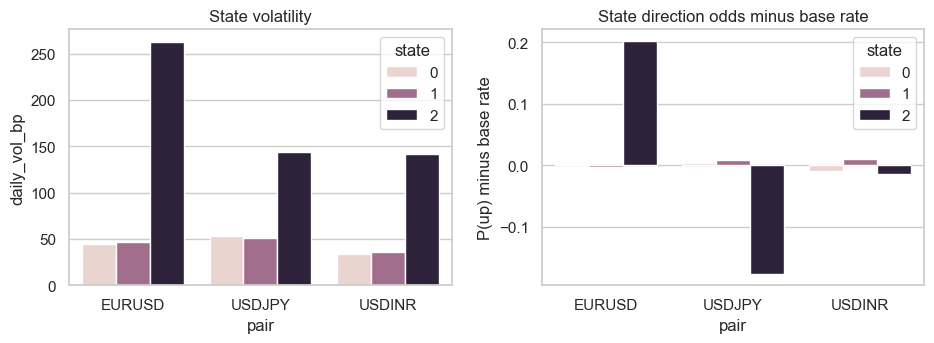

In [14]:
# Inspect what the HMM learned, not just its score — the two panels ask
# whether the states separate by volatility or by direction.
fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.6))
sns.barplot(states_df, x="pair", y="daily_vol_bp", hue="state", ax=axes[0])
axes[0].set_title("State volatility")
sns.barplot(states_df, x="pair", y="p_up_minus_base", hue="state", ax=axes[1])
axes[1].set_title("State direction odds minus base rate")
axes[1].set_ylabel("P(up) minus base rate")
plt.tight_layout()

The HMM's states separate by volatility, not direction: two near-identical calm
states and a rare stormy one, none with usable direction odds. It is a
turbulence detector; notebook 2 puts that to proper use.

## 7. Comparison against the benchmark

Block 6, the final test set: does anything beat the persistence floor by more
than noise? The gap gets an uncertainty range built by resampling whole
stretches of days (a moving-block bootstrap) — nearby days behave alike, so
resampling single days would understate the uncertainty.

In [15]:
def block_bootstrap_ci(diff, block_len=10, n_boot=1000, seed=42):
    rng = np.random.default_rng(seed)
    n = len(diff)
    means = []
    for _ in range(n_boot):
        idx = np.concatenate([np.arange(s, s + block_len)
                              for s in rng.integers(0, n - block_len + 1,
                                                    int(np.ceil(n / block_len)))])[:n]
        means.append(diff[idx].mean())
    return np.quantile(means, [0.025, 0.975])

final = []
for pair in PAIRS:
    train, test = split_by_block(datasets[pair], block6, purge=settings.direction_k)
    y = test[TARGET_COLUMN].to_numpy()
    m = make_b1(settings.seed).fit(train[MODEL_FEATURES], train[TARGET_COLUMN])
    pred = m.predict(test[MODEL_FEATURES])
    floor = MajorityPersistenceBaseline().fit(train, train[TARGET_COLUMN]).predict(test)

    # per-class recall difference, bootstrapped on the paired per-day hits
    gap = balanced_accuracy_score(y, pred) - balanced_accuracy_score(y, floor)
    # bootstrap the per-day agreement difference as a proxy interval on the gap
    diff = (pred == y).astype(float) - (floor == y).astype(float)
    lo, hi = block_bootstrap_ci(diff, seed=settings.seed)
    final.append({"pair": pair, "n": len(y),
                  "balanced_acc_gap_pp": round(gap * 100, 1),
                  "accuracy_gap_ci_lo": round(lo * 100, 1),
                  "accuracy_gap_ci_hi": round(hi * 100, 1),
                  "excludes_zero": bool(lo > 0 or hi < 0)})
final = pd.DataFrame(final)
final

,pair,n,balanced_acc_gap_pp,accuracy_gap_ci_lo,accuracy_gap_ci_hi,excludes_zero
0,EURUSD,322,6.4,3.4,22.4,True
1,USDJPY,322,1.6,-1.2,18.3,False
2,USDINR,322,1.4,-0.6,16.5,False


In [16]:
published = pd.read_csv("../outputs/case_study/tables/paired_diffs_baselines.csv")
published = published.query("scope == 'block6_confirmation' and comparison == 'B1-B0'")
published[["pair", "balacc_diff", "balacc_ci_lo", "balacc_ci_hi", "balacc_excludes_zero"]] \
    .assign(balacc_diff=lambda d: (d["balacc_diff"] * 100).round(1),
            balacc_ci_lo=lambda d: (d["balacc_ci_lo"] * 100).round(1),
            balacc_ci_hi=lambda d: (d["balacc_ci_hi"] * 100).round(1))

,pair,balacc_diff,balacc_ci_lo,balacc_ci_hi,balacc_excludes_zero
0,EURUSD,6.4,-1.8,15.5,False
6,USDINR,1.4,-5.3,8.7,False
12,USDJPY,1.6,-4.9,8.8,False


One honest wrinkle in the quick check above: it scores plain accuracy, which
rewards leaning on the commonest outcome, and on that crude score EURUSD's
range just excludes zero. That is exactly why the study's registered metric is
balanced accuracy. The full study (script `03_run_baselines.py`, which
bootstraps the balanced-accuracy gap itself) puts the intervals at **EURUSD
+6.4pp [−1.8, +15.5], USDJPY +1.6pp [−4.9, +8.8], USDINR +1.4pp [−5.3, +8.7]**
(pp = percentage points; the brackets are the uncertainty range). Every range
includes zero — "no advantage at all" is within the noise on the metric that
can't be gamed by majority-leaning.

### Conclusion

- No model beats "the next period repeats the last one" by more than its
  uncertainty range, on any pair.
- The durable finding is about confidence, not accuracy: gradient boosting's
  probabilities are overconfident, logistic's roughly honest — visible only
  because probability quality was scored at all.
- Direction has no memory, but size does. Notebook 2 takes the size question,
  and the planning-rate one.